In [175]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
from itertools import groupby
from operator import itemgetter
import matplotlib.colors as colors
import seaborn as sns

In [2]:
f = h5py.File("../hdf5_files/event_93970574.h5")
list(f.keys())

['positions', 'times', 'traces']

In [3]:
tr1 = f["traces"]
tr1.shape

(14, 96, 2, 65536)

In [4]:
files = glob.glob("../hdf5_files/*")

In [5]:
for fi in files:
    try:
        with h5py.File(fi, 'r') as f:
            print(f"{fi}: {f['traces'].shape}")
    except OSError:
        print(f"{fi}: SKIPPED (File is corrupted or invalid HDF5)")

../hdf5_files/event_211274458.h5: (19, 96, 2, 65536)
../hdf5_files/event_256893462.h5: (21, 96, 2, 65536)
../hdf5_files/event_216741224.h5: (19, 96, 2, 65536)
../hdf5_files/event_236442324.h5: (22, 96, 2, 65536)
../hdf5_files/event_242764060.h5: SKIPPED (File is corrupted or invalid HDF5)
../hdf5_files/event_212636270.h5: (20, 96, 2, 65536)
../hdf5_files/event_219288990.h5: (21, 96, 2, 65536)
../hdf5_files/event_239076863.h5: (22, 96, 2, 65536)
../hdf5_files/event_222684112.h5: (20, 96, 2, 65536)
../hdf5_files/event_221627323.h5: (21, 96, 2, 65536)
../hdf5_files/event_98790022.h5: (19, 96, 2, 65536)
../hdf5_files/event_109687805.h5: (18, 96, 2, 65536)
../hdf5_files/event_126350302.h5: (22, 96, 2, 65536)
../hdf5_files/event_222848068.h5: (20, 96, 2, 65536)
../hdf5_files/event_258517814.h5: (21, 96, 2, 65536)
../hdf5_files/event_239712228.h5: (22, 96, 2, 65536)
../hdf5_files/event_211047255.h5: (20, 96, 2, 65536)
../hdf5_files/event_95818679.h5: (16, 96, 2, 65536)
../hdf5_files/event_259

In [7]:
sorted_nums = [0,1,2,3,4,5,7,8]
ranges = []

for _, g in groupby(enumerate(sorted_nums), lambda pair: pair[1] - pair[0]):
    print(g)
    print(list(t[1] for t in g))
    # group = list(map(itemgetter(1), g))
    
    # if len(group) > 1:
    #     ranges.append(f"{group[0]}-{group[-1]}")
    # else:
    #     ranges.append(str(group[0]))

[0, 1, 2, 3, 4, 5]
[7, 8]


In [8]:
def format_consecutive_ranges(numbers):
    sorted_nums = sorted(set(numbers)) 
    ranges = []
    
    # Group numbers where (number - index) is identical
    for _, g in groupby(enumerate(sorted_nums), lambda pair: pair[1] - pair[0]):
        group = [t[1] for t in g]
        
        if len(group) > 1:
            ranges.append(f"{group[0]}-{group[-1]}")
        else:
            ranges.append(str(group[0]))
            
    return ", ".join(ranges)

In [9]:
traces_reduced = h5py.File(files[0])["traces"][:9]

In [10]:
traces_reduced.shape

(9, 96, 2, 65536)

In [198]:
traces = np.array(h5py.File(files[0])["traces"])

for i in range(traces.shape[0]):
    all0 = []
    one0 = []
    for j in range(traces.shape[1]):
        if (traces[i,j,j%2]==0).all() and (traces[i,j,(j+1)%2]==0).all():
            all0.append(j)
        elif (traces[i,j,j%2]==0).all() or (traces[i,j,(j+1)%2]==0).all():
            one0.append(j)
    print(f"stn {i} | empty channels:{format_consecutive_ranges(all0)} | one polarization empty: {format_consecutive_ranges(one0)}")

stn 0 | empty channels:44-95 | one polarization empty: 0, 43
stn 1 | empty channels:46-95 | one polarization empty: 0, 45
stn 2 | empty channels:49-95 | one polarization empty: 0, 48
stn 3 | empty channels:47-95 | one polarization empty: 0, 46
stn 4 | empty channels:48-95 | one polarization empty: 0, 47
stn 5 | empty channels:48-95 | one polarization empty: 0, 47
stn 6 | empty channels:48-95 | one polarization empty: 0, 47
stn 7 | empty channels:44-95 | one polarization empty: 0, 43
stn 8 | empty channels:46-95 | one polarization empty: 0, 45
stn 9 | empty channels:48-95 | one polarization empty: 0, 47
stn 10 | empty channels:44-95 | one polarization empty: 0, 43
stn 11 | empty channels:43-95 | one polarization empty: 0, 42
stn 12 | empty channels:47-95 | one polarization empty: 0, 46
stn 13 | empty channels:48-95 | one polarization empty: 0, 47
stn 14 | empty channels:45-95 | one polarization empty: 0, 44
stn 15 | empty channels:46-95 | one polarization empty: 0, 45
stn 16 | empty cha

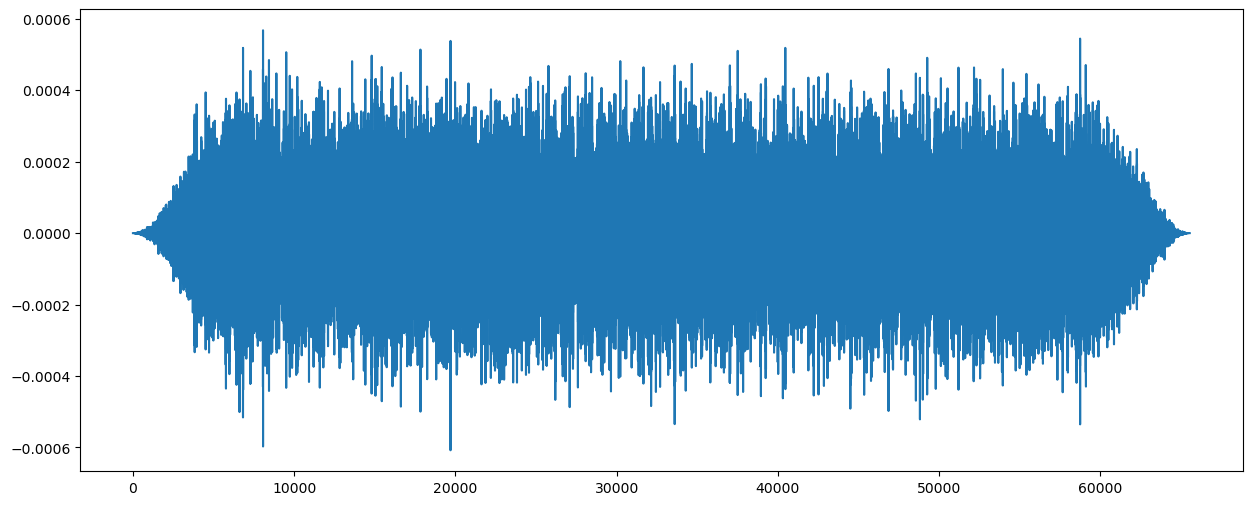

In [12]:
plt.figure(figsize=(15,6))
plt.plot(traces[5,0,1])
plt.show()

In [13]:
pos = h5py.File(files[0])["positions"]

In [14]:
pos.shape

(19, 96, 3)

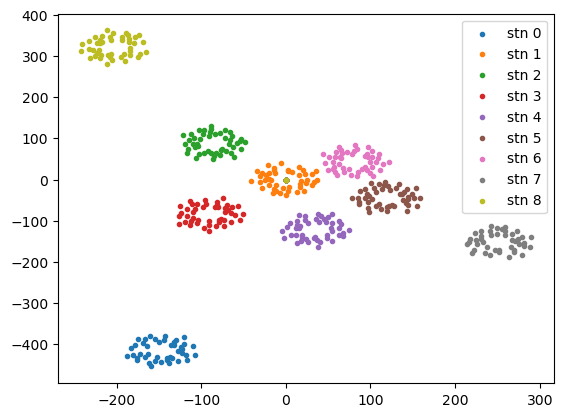

In [15]:
for i in range(9):
    plt.scatter(pos[i, :48, 0], pos[i, :48, 1], label=f"stn {i}", marker=".")
plt.legend()
plt.show()

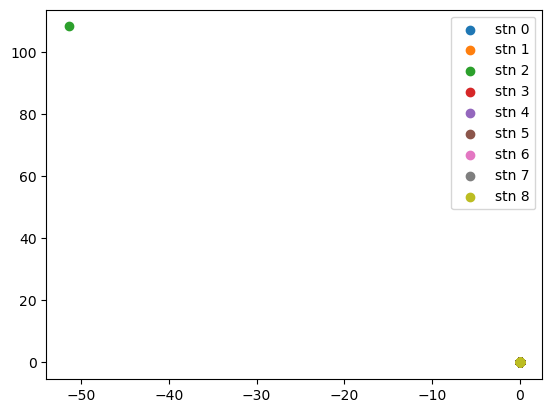

In [16]:
for i in range(9):
    plt.scatter(pos[i, 48:, 0], pos[i, 48:, 1], label=f"stn {i}")
plt.legend()
plt.show()

In [17]:
pos[i, 48:, 1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [18]:
new = traces.reshape(-1, 2, traces.shape[-1])

In [19]:
new

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-3.76888149e-10, -2.67351037e-09,  5.06797899e-09, ...,
         -2.01498716e-09, -4.51274886e-09,  4.13092112e-09]],

       [[ 7.95239285e-10,  9.09445822e-10,  1.48182274e-09, ...,
          1.10032977e-09, -7.08920012e-11, -3.62579032e-09],
        [ 3.12279467e-09, -4.06015667e-09,  6.71711724e-10, ...,
          4.35227432e-09, -4.27716718e-09, -1.89233478e-09]],

       [[-3.15264767e-09,  4.59134671e-09,  1.40960335e-09, ...,
          5.35745486e-10, -2.49153286e-09, -2.52605108e-09],
        [-5.10449898e-09,  4.97900133e-09, -2.13559107e-09, ...,
         -2.41268980e-09,  2.65316348e-09, -2.89391318e-10]],

       ...,

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000

In [20]:
np.any(np.all(new==0,axis=2), axis=1)

array([ True, False, False, ...,  True,  True,  True], shape=(1824,))

In [21]:
np.sum(np.any(np.all(new==0,axis=2), axis=1))

np.int64(1011)

In [22]:
deleted = new[~np.any(np.all(new==0,axis=2), axis=1)]

In [23]:
reduced = deleted.reshape(-1, deleted.shape[-1])

In [24]:
reduced

array([[ 7.95239285e-10,  9.09445822e-10,  1.48182274e-09, ...,
         1.10032977e-09, -7.08920012e-11, -3.62579032e-09],
       [ 3.12279467e-09, -4.06015667e-09,  6.71711724e-10, ...,
         4.35227432e-09, -4.27716718e-09, -1.89233478e-09],
       [-3.15264767e-09,  4.59134671e-09,  1.40960335e-09, ...,
         5.35745486e-10, -2.49153286e-09, -2.52605108e-09],
       ...,
       [ 2.46339666e-09, -3.54090817e-09,  1.17999596e-09, ...,
         2.20396151e-09, -3.42674698e-09,  4.16285686e-09],
       [-2.47343435e-09,  1.27414190e-09, -2.54243659e-09, ...,
         8.42773312e-09, -1.01552547e-10, -4.63236738e-09],
       [-6.77147705e-09, -5.61902958e-09,  9.22983896e-09, ...,
        -2.33329265e-09, -6.12353787e-09,  1.18056428e-08]],
      shape=(1626, 65536))

In [25]:
reduced[0,-6001]

np.float64(3.585093558377182e-05)

In [26]:
reduced[:, 6000:-6000]

array([[ 1.97083883e-04,  7.53502374e-05, -1.65739324e-04, ...,
        -4.60838159e-07, -7.78981896e-05,  3.58509356e-05],
       [ 6.26227382e-05,  1.20979409e-04, -7.12886708e-05, ...,
        -5.70676459e-05,  1.51159644e-04, -5.87523570e-05],
       [ 5.26371186e-05, -1.43531240e-04,  9.12030387e-05, ...,
         1.65096850e-04, -6.71044669e-06, -1.70016770e-04],
       ...,
       [ 1.38382795e-04,  1.39538682e-04, -2.61368119e-04, ...,
        -3.47769828e-05,  1.29859259e-04, -1.99149051e-05],
       [-1.00326602e-04, -7.16774671e-05,  7.24163386e-05, ...,
        -2.10619273e-04,  1.69982723e-04,  1.72014050e-04],
       [-1.01129352e-07, -4.72540941e-05,  3.44109321e-05, ...,
        -1.74881577e-05, -1.08541013e-04,  3.47143262e-05]],
      shape=(1626, 53536))

In [28]:
demoname="demo"
demo = np.empty(shape=[4,4,1,5])
if demo.shape[2] != 2 or np.argmax(demo.shape)!= 3:
    print(f"{demoname}: The shape seems to mismatch, got {demo.shape}. It should be (stn, chn, 2, time_bin (biggest))")

demo: The shape seems to mismatch, got (4, 4, 1, 5). It should be (stn, chn, 2, time_bin (biggest))


In [29]:
def modify_data(raw_traces, trim):
    new = raw_traces.reshape(-1, 2, raw_traces.shape[-1]) #stack all stations together
    deleted = new[~np.any(np.all(new==0,axis=2), axis=1)] #delete all channels if at least one of the polarization has all 0 data
    reduced = deleted.reshape(-1, deleted.shape[-1]) #stack all polarizations together, making it 2D array of (channels, time_bins)
    return reduced[:, trim:-trim]

def read_file(fn, trim):
    try:
        with h5py.File(fn, 'r') as f:
            traces = f["traces"][:9]
            if traces.shape[2] != 2 or np.argmax(traces.shape)!= 3:
                print(f"{fn}: The shape seems to mismatch, got {traces.shape}. It should be (stn, chn, 2(pol), time_bin (biggest))")
                sys.exit(1)
            return modify_data(traces, trim)
    except Exception as e:
        print(f"{fn}: SKIPPED (File is corrupted or invalid HDF5)")
        sys.exit(1)
    

In [30]:
tr = read_file(files[0], 6000)
tr

array([[ 1.97083883e-04,  7.53502374e-05, -1.65739324e-04, ...,
        -4.60838159e-07, -7.78981896e-05,  3.58509356e-05],
       [ 6.26227382e-05,  1.20979409e-04, -7.12886708e-05, ...,
        -5.70676459e-05,  1.51159644e-04, -5.87523570e-05],
       [ 5.26371186e-05, -1.43531240e-04,  9.12030387e-05, ...,
         1.65096850e-04, -6.71044669e-06, -1.70016770e-04],
       ...,
       [-3.09111653e-05, -2.24829041e-04,  1.92620870e-04, ...,
         1.47478364e-05, -1.04551175e-04,  1.12880091e-05],
       [-2.42953382e-05, -2.03691352e-04,  7.47011761e-05, ...,
        -1.13373401e-04,  5.90259873e-05,  1.40351754e-04],
       [-4.69533457e-05, -3.28931957e-05,  4.95859721e-05, ...,
        -1.82249911e-04,  2.75329155e-04, -3.97556170e-05]],
      shape=(804, 53536))

In [31]:
fi = reduced[:, 6000:-6000]

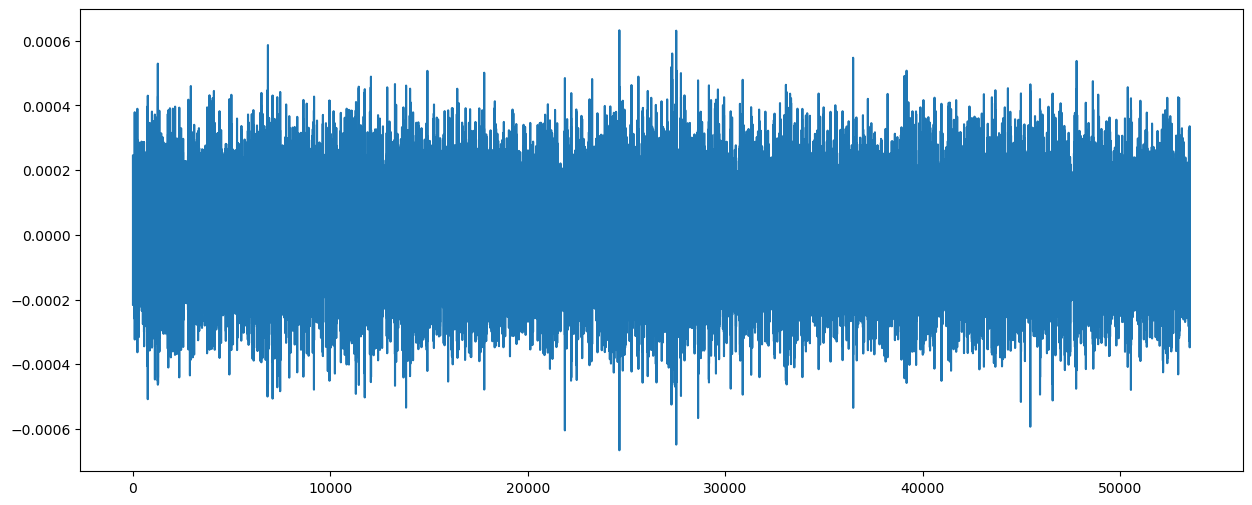

410


In [119]:
idx = np.random.randint(0, len(fi))
plt.figure(figsize=(15,6))
plt.plot(fi[idx])
plt.show()
print(idx)

In [33]:
def calc_rms(trace, length):
    return np.sqrt(np.mean(np.square(trace[:length])))

In [120]:
diff_length = np.arange(100, 20000, 100)
rmses = [calc_rms(fi[idx], length) for length in diff_length]

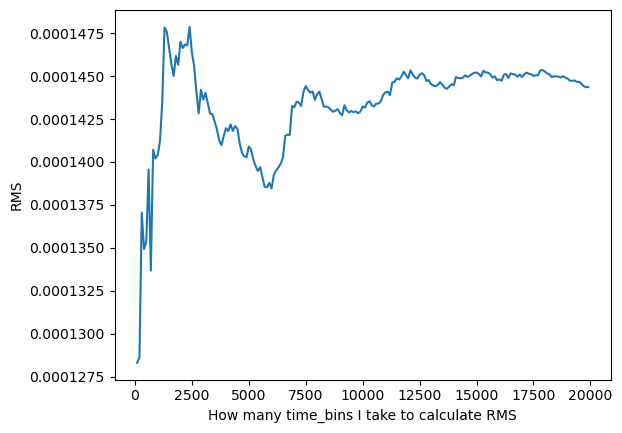

In [121]:
plt.plot(diff_length, rmses)
plt.xlabel("How many time_bins I take to calculate RMS")
plt.ylabel("RMS")
plt.show()

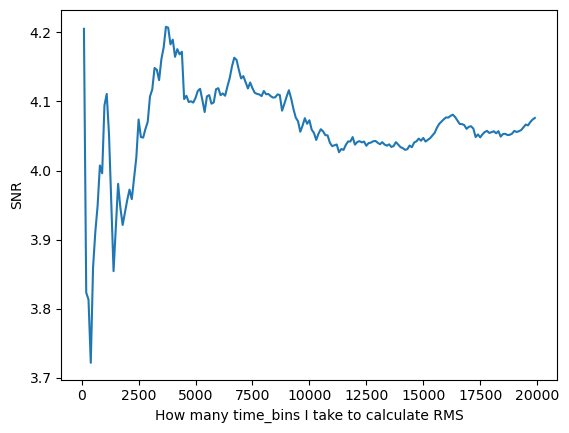

In [115]:
plt.plot(diff_length, np.max(fi[idx])/rmses)
plt.xlabel("How many time_bins I take to calculate RMS")
plt.ylabel("SNR")
plt.show()

In [167]:
def remove_signal(trace, sig_window, rms, threshold):
    if np.max(trace)/rms > threshold:
        sig = np.argmax(trace)
        return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1)), True
    return trace, False

In [123]:
rms = calc_rms(fi[0], 7500)

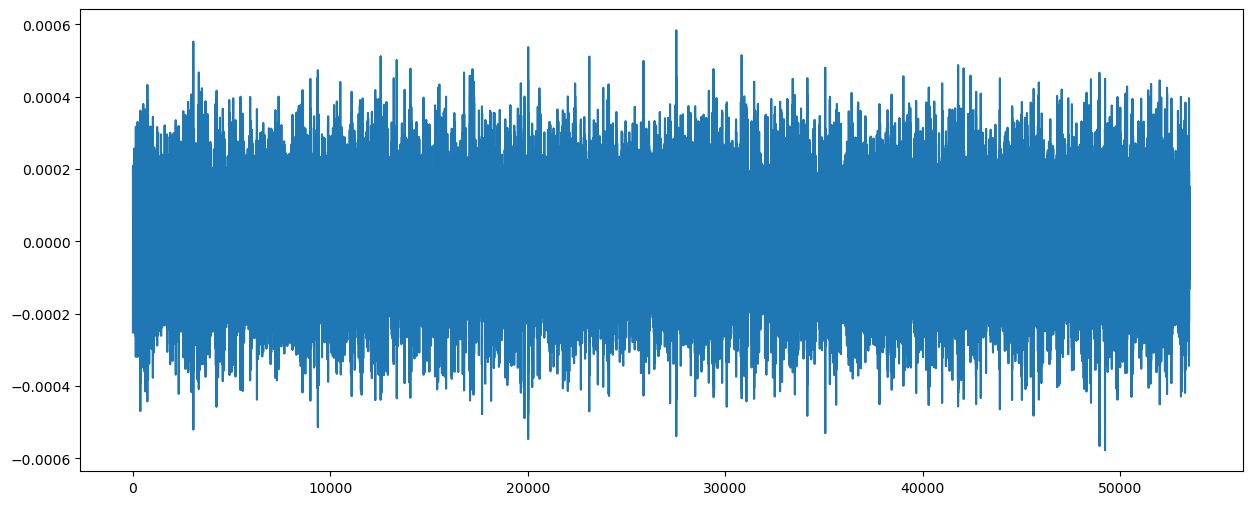

163


In [168]:
idx = np.random.randint(0, len(fi))
plt.figure(figsize=(15,6))
plt.plot(remove_signal(fi[idx], 20, rms, 4.8)[0])
plt.show()
print(idx)

In [169]:
def get_reals(traces, dur, sig_window, rms, threshold):
    reals = []
    n_removed = 0
    for trace in traces:
        new, rem = remove_signal(trace, sig_window, rms, threshold)
        to_consider = new[:-(len(new)%dur)]
        reals.append(np.split(to_consider, len(to_consider)/dur))
        if rem:
            n_removed += 1
        
    print(f"{n_removed}/{len(traces)} had above SNR {threshold} signal")
    return np.vstack(reals)

def make_cov(traces, duration, sig_window, rms_window, threshold):
    rms = calc_rms(traces[0], rms_window)
    reals = np.array(get_reals(traces, duration, sig_window, rms, threshold))
    N = len(reals)

    if N==0:
        return np.zeros((duration, duration)), N

    return np.cov(reals.T), N

In [172]:
cov, N = make_cov(tr, 100, 20, 7500, 4.8)
print(f"Number of Realization: {N}")

147/804 had above SNR 4.8 signal
Number of Realization: 429993


In [180]:
def draw_cov(cov, N, dur):
    # Make plots
    plt.figure()
    sns.heatmap(cov, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
    plt.suptitle(files[0].rsplit('/', 1)[-1].split('.', 1)[0])
    plt.title(f"Size: {dur} ({dur*5} ns), {N} realizations")
    plt.tight_layout()

    plt.show()

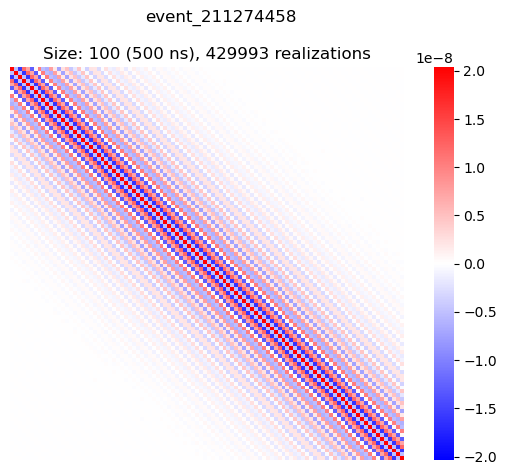

In [181]:
draw_cov(cov, N, 100)

In [194]:
def draw_1D(cov, x_time, dur):
    
    # Plot!
    plt.figure(figsize=(12,6))
    plt.axhline(y=0, c="gray", linestyle="--")
    plt.plot(x_time[:50], cov[0, :50])
    plt.scatter(x_time[:50], cov[0, :50], marker=".")

    plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
    plt.ylabel(r"Cov($\Delta t_{i,j}$)")
    
    plt.suptitle(files[0].rsplit('/', 1)[-1].split('.', 1)[0])
    plt.title(f"1D function of the first row for first 50 bins. Size: {dur} ({dur*5} ns), {N} realizations")
    plt.tight_layout()

    plt.show()

In [189]:
with h5py.File(files[0], 'r') as f:
    x_time = f["times"][0,1,0]

In [190]:
x_time

array([0.00000e+00, 5.00000e+00, 1.00000e+01, ..., 3.27665e+05,
       3.27670e+05, 3.27675e+05], shape=(65536,))

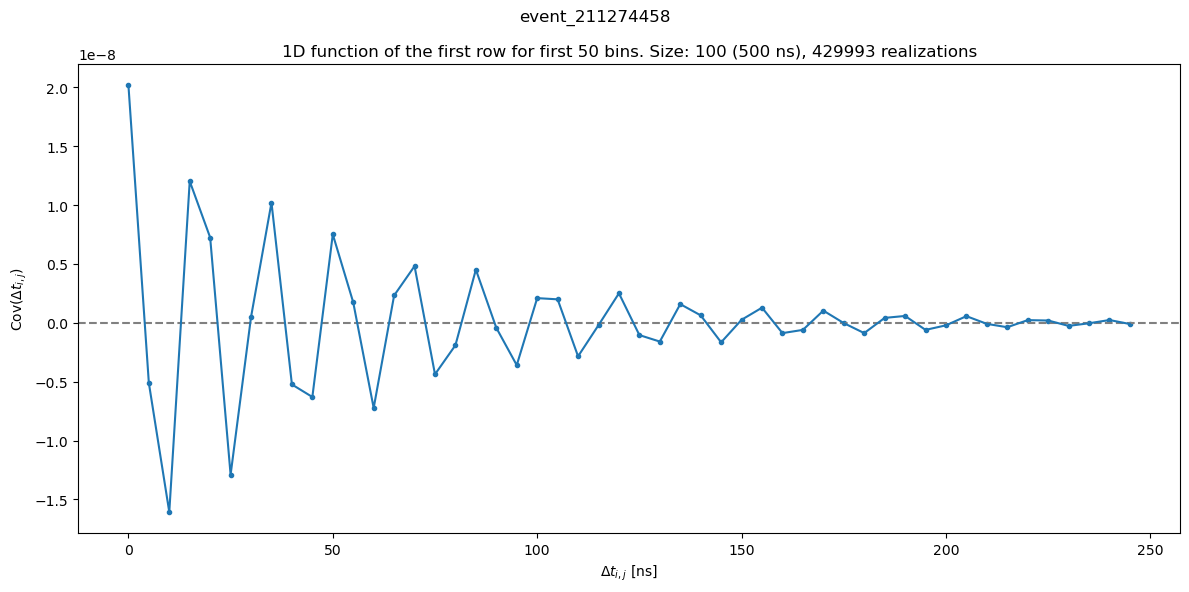

In [195]:
draw_1D(cov, x_time, 100)